# Modelatge
En aquest notebook aplicarem models d'aprenentatge no supervisats de clustering per agrupar els barris segons les seves característiques. 

**to do**
- Preprocess
    - StandardScaler
    - PCA
- Models
    - Kmeans
    - DBSCAN
    - AglomerativeClustering
- Conclusions i resultats

**Funcions a definir:**
- funcio per gràficar pca i variança explicada
- funcio per silouette i inercia
- funcio per kmeans i graficar clusters
- funcio per agglomerative i graficar clusters
- funcio per silouette i inercia





# Llibreries i configuracio

In [1]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

# Evitar warning
os.environ["OMP_NUM_THREADS"] = "1"

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

sns.set_theme()

# Carrega dels datasets

In [2]:
BASE_DIR = Path('..')
DATA_DIR = BASE_DIR/'data'
RESULTS_DIR = BASE_DIR/'results'/'figs'


df_2015 = pd.read_csv(DATA_DIR / 'modelling' / 'df_2015.csv')
df_2023 = pd.read_csv(DATA_DIR / 'modelling' / 'df_2023.csv')
df_deltes = pd.read_csv(DATA_DIR / 'modelling' / 'df_deltes.csv')

print("Dataset 2015: ", df_2015.shape)
print("Dataset 2023: ", df_2023.shape)
print("Dataset Deltes: ", df_deltes.shape)

Dataset 2015:  (73, 14)
Dataset 2023:  (73, 14)
Dataset Deltes:  (73, 14)


# Funcions auxiliars 

In [34]:
def extreure_codi_barri(df:pd.DataFrame): 
    codi_barri = df["codi_barri"]
    X = df[[col for col in df.columns if col != "codi_barri"]].copy()
    return codi_barri, X


def grafic_var_explicada(pca: np.array, target: float, titol: str, nom_arxiu: str):
    cumsum = np.cumsum(pca.explained_variance_ratio_)
    n_components = np.argmax(cumsum >= target) + 1
    var_explicada = pca.explained_variance_ratio_
    
    plt.figure(figsize=(8,4))
    plt.bar(range(1, len(var_explicada)+1), var_explicada, alpha=0.6, label="Var Explicada")
    plt.plot(range(1, len(var_explicada)+1), cumsum, linewidth=1, marker = 'o', label= "Var Explicada Cum",c ="r")
    plt.axhline(0.95, color='green', linestyle='--', label='95%')
    plt.plot([n_components, n_components], [0, target], "k:")
    plt.plot([0, n_components], [target, target], "k:")
    plt.plot(n_components, target, "ko")
    plt.xlabel("Dimensions")
    plt.ylabel("Explained Variance")
    plt.title(f"{titol} | n_components = {n_components}")
    plt.legend()
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / f"{nom_arxiu}")
    plt.show()


def evaluacio_cluster(clusterer: KMeans, X: np.array, labels: np.array, nom_model: str, tipo_dades: str):
    resultats = {
        "model": nom_model,
        "tipo_dades": tipo_dades,
        "n_clusters" : len(set(labels))
    }

    resultats["silhouette"] = silhouette_score(X, labels)
    
    if isinstance(clusterer, KMeans):  # inercia només per kmeans
        resultats["inercia"] = clusterer.inertia_
    
    
    return resultats

def plot_seleccio_kmeans(results: pd.DataFrame, nom_dades: str, nom_fitxer: str):
    fig = plt.figure(figsize=(15, 5))
    ax1 = fig.add_subplot(1, 2, 1)
    ax2 = fig.add_subplot(1, 2, 2)
    sns.lineplot(results, y = "inercia", x = "n_clusters", hue = "tipo_dades", ax=ax1, style="tipo_dades", markers=['o', 'D'])
    sns.lineplot(results, y = "silhouette", x = "n_clusters", hue = "tipo_dades", ax= ax2, style="tipo_dades", markers = ['o', 'D'])
    plt.suptitle(f"Selecció de k amb KMeans ({nom_dades})")
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / f"{nom_fitxer}")
    plt.show()

def plot_seleccio_agg(results: pd.DataFrame, nom_dades: str, nom_fitxer: str):
    plt.figure(figsize=(8, 5))
    sns.lineplot(results, y = "silhouette", x = "n_clusters", hue = "tipo_dades", style="tipo_dades", markers = ['o', 'D'])
    plt.title(f"Selecció de K amb Silhouette amb Agglomerative Clustering ({nom_dades})")
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / f"{nom_fitxer}")
    plt.show()

# Preprocessament
- Separar variables de codi_barri
- Escalar els conjunts de dades
- Aplicar PCA
- Aplicar clustering amb pca i amb escalat
- Seleccionar nombre de clusters
- Interpretació dels clústers

In [4]:
# Separem la columna de codi barri
codi_barri_15, X_15 = extreure_codi_barri(df_2015)
codi_barri_23, X_23 = extreure_codi_barri(df_2023)
codi_barri_deltes, X_deltes = extreure_codi_barri(df_deltes)

In [5]:
# Escalem les dades
scaler = StandardScaler()

X_15_scaled = scaler.fit_transform(X_15)
X_23_scaled = scaler.fit_transform(X_23)
X_deltes_scaled = scaler.fit_transform(X_deltes)

# Dades 2015

## PCA (Principal Component analysis)

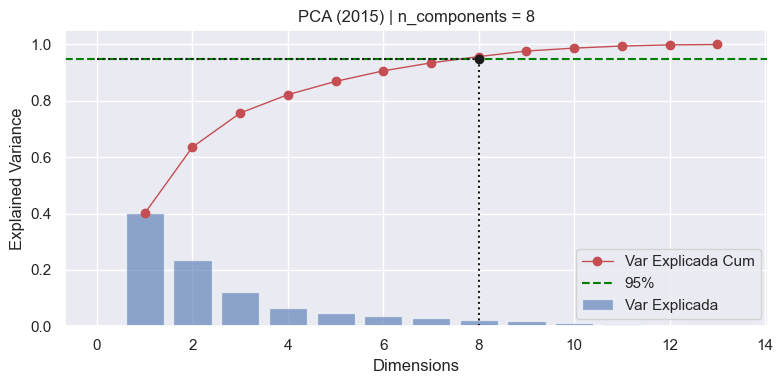

In [6]:
# Probarem PCA per reduir la dimensionalitat del conjunt de dades
pca_15 = PCA(random_state= 42)
pca_embedding = pca_15.fit_transform(X_15_scaled)
grafic_var_explicada(pca_15, 0.95, "PCA (2015)", "variança_explicada_15.png")

**Observacions:**
- Es pot observar que es necessiten els 8 principal components per explicar el 95% de la variança. 5 per explicar el 90%.

In [7]:
# apliquem pca amb el n_components obtingut anteriorment
n_components_15 = 8

pca_15_fixed = PCA(n_components= n_components_15, random_state= 42)
X_pca_15_fixed = pca_15_fixed.fit_transform(X_15_scaled)

# Mostrem els resultats i components
X_pca_df = pd.DataFrame(X_pca_15_fixed, columns=[f'PC{i}' for i in range(1, n_components_15 + 1)], index=df_2015['codi_barri'])
X_pca_df.head()


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8
codi_barri,,,,,,,,
1,2.355191,4.490169,1.126331,-1.615403,1.318966,-0.282564,-0.993202,1.305772
2,5.910670,6.495680,-1.196214,-0.596422,0.320486,-0.553012,2.466511,-0.847702
3,3.092488,3.295516,-1.190071,-1.250329,-0.697302,-0.473648,0.586394,0.859204
4,4.648373,4.508592,-0.723265,-0.894906,-0.287535,-0.869041,0.112567,0.222926
5,1.805701,0.316673,0.881500,0.497075,-0.832472,0.520835,-0.554909,-0.072050


## KMeans

In [8]:
# Comparem clusters amb pca vs dades escalades
valors_k = range(2, 10)
resultats_clusters_2015 = []
for k in valors_k:
    clusterer_scaled = KMeans(n_clusters = k, n_init = 20, random_state = 42)
    cluster_labels_scaled = clusterer_scaled.fit_predict(X_15_scaled)
    resultats_clusters_2015.append(evaluacio_cluster(clusterer_scaled, X_15_scaled, cluster_labels_scaled, f"KMeans_{k}", "escalades"))

    clusterer_pca = KMeans(n_clusters = k, n_init = 20, random_state = 42)
    cluster_labels_pca = clusterer_pca.fit_predict(X_pca_15_fixed)
    resultats_clusters_2015.append(evaluacio_cluster(clusterer_pca, X_pca_15_fixed, cluster_labels_pca, f"KMeans_{k}", "pca"))


# Convertim a dataframe
resultats_2015_df = pd.DataFrame(resultats_clusters_2015)
resultats_2015_df

,model,tipo_dades,n_clusters,silhouette,inercia
0,KMeans_2,escalades,2,0.292254,659.826884
1,KMeans_2,pca,2,0.306500,619.181894
2,KMeans_3,escalades,3,0.311000,525.130666
3,KMeans_3,pca,3,0.327722,485.412025
4,KMeans_4,escalades,4,0.286169,449.629904
5,KMeans_4,pca,4,0.306513,410.189102
6,KMeans_5,escalades,5,0.308905,375.862366
7,KMeans_5,pca,5,0.331401,336.758874
8,KMeans_6,escalades,6,0.264832,325.669483
9,KMeans_6,pca,6,0.272640,286.741665


**Observacions:**
- Es pot observar a la taula que els valors den pca obtenen resultats lleugerament superiors en silhouette i inercia.
- Destaquen els models amb 3 i 5 clusters. 
Es veu millor de manera gràfica.

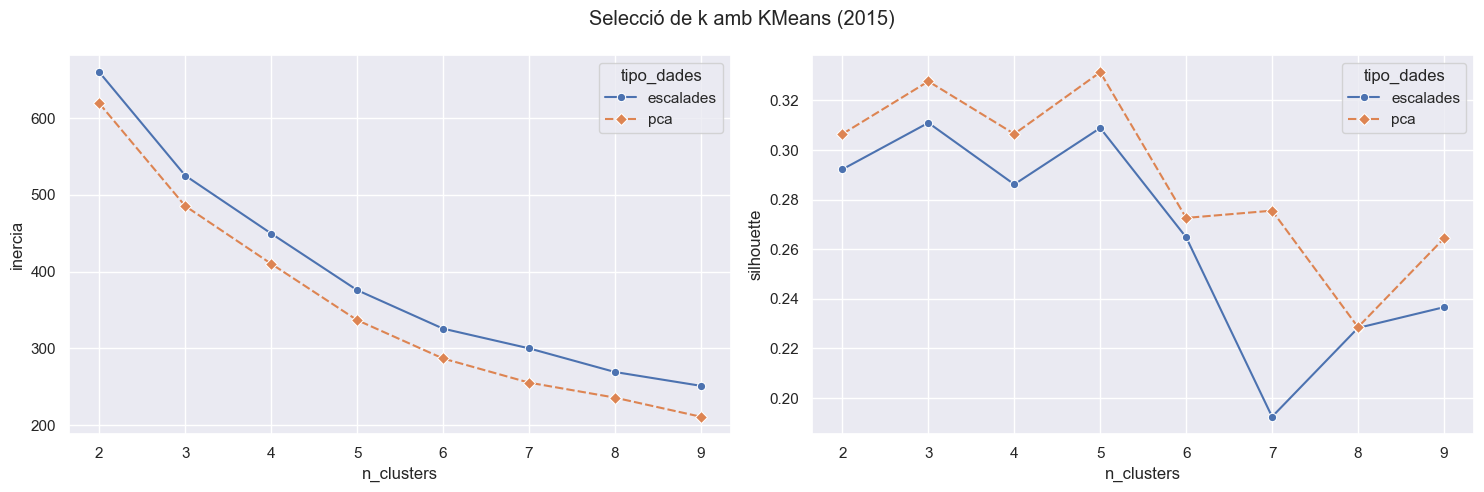

In [35]:
plot_seleccio_kmeans(resultats_2015_df, "2015", "seleccio_k_2015.png")

**Observacions:**
- Tal i com es menciona anteriorment, el nombre de clusters òptim són 3 o 5 clusters, en ambdós casos s' obté un bon valor de silhouette, i es pot considerar el colze en el gràfic de la inèrcia. 
- Un fet clar, és que les dades amb pca aplicada, obtenen lleugerament millors resultats.

## Agglomerative Clustering

In [14]:
# Comparem clusters amb pca vs dades escalades
valors_k = range(2, 10)
agg_resultats_15 = []
for k in valors_k:
    agg_scaled = AgglomerativeClustering(n_clusters = k)
    agg_labels = agg_scaled.fit_predict(X_15_scaled)
    agg_resultats_15.append(evaluacio_cluster(agg_scaled, X_15_scaled, agg_labels, f"KMeans_{k}", "escalades"))

    agg_pca = AgglomerativeClustering(n_clusters = k)
    agg_labels = agg_pca.fit_predict(X_pca_15_fixed)
    agg_resultats_15.append(evaluacio_cluster(agg_pca, X_pca_15_fixed, agg_labels, f"KMeans_{k}", "pca"))


# Convertim a dataframe
agg_resultats_15_df = pd.DataFrame(agg_resultats_15)
agg_resultats_15_df

,model,tipo_dades,n_clusters,silhouette
0,KMeans_2,escalades,2,0.292254
1,KMeans_2,pca,2,0.312019
2,KMeans_3,escalades,3,0.311000
3,KMeans_3,pca,3,0.327740
4,KMeans_4,escalades,4,0.322205
5,KMeans_4,pca,4,0.260716
6,KMeans_5,escalades,5,0.310245
7,KMeans_5,pca,5,0.265730
8,KMeans_6,escalades,6,0.255842
9,KMeans_6,pca,6,0.261100


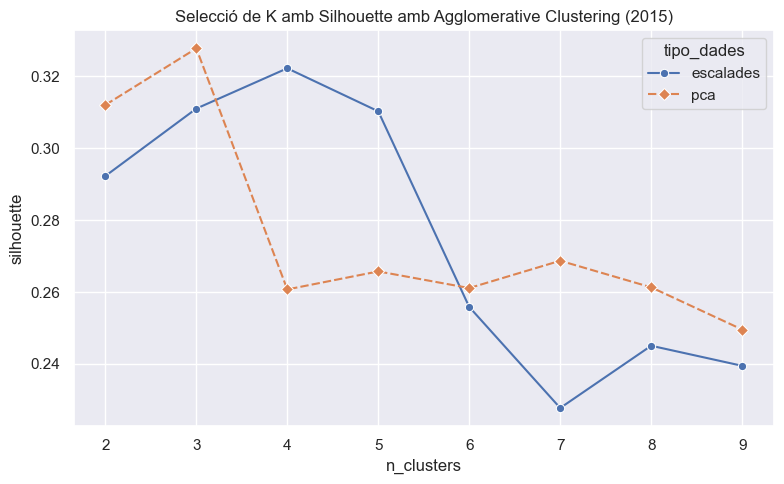

In [36]:
plot_seleccio_agg(agg_resultats_15_df, "2015", "seleccio_k_2015_agg.png")

**Observacions:**
- Scores de silhouette similars a les obtingudes amb KMeans. En aquest cas, el nombre òptim de clusters és 3. 

# Dades 2023

## PCA (Principal Component Analysisi)

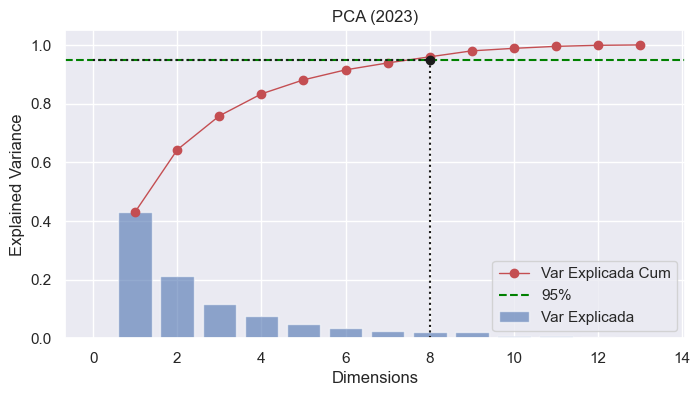

In [90]:
pca_23 = PCA(random_state= 42)
pca_embedding = pca_23.fit_transform(X_23_scaled)
grafic_var_explicada(pca_23, 0.95, "PCA (2023)", "variança_explicada_23.png")

**Observacions:**
- Per al dataset de 2023 el nombre de dimensions necessari per explicar el 95% de la variança són 8

In [29]:
# apliquem pca amb el n_components obtingut anteriorment
n_components_23 = 8

pca_23_fixed = PCA(n_components= n_components_23, random_state= 42)
X_pca_23_fixed = pca_23_fixed.fit_transform(X_23_scaled)

# Mostrem els resultats i components
X_pca_df = pd.DataFrame(X_pca_23_fixed, columns=[f'PC{i}' for i in range(1, n_components_23 + 1)], index=df_2023['codi_barri'])
X_pca_df.head()


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8
codi_barri,,,,,,,,
1,2.209646,3.821339,-1.207177,-0.125274,-0.769517,-0.726958,-0.533644,0.813306
2,4.744372,5.883607,0.057098,-1.813898,-1.523925,-0.320689,-0.612631,0.158705
3,3.258722,3.273210,0.584971,-1.578936,-0.076243,-0.482168,1.298441,0.491486
4,4.819415,3.959374,0.544561,-1.620148,-0.267873,-0.247366,0.959492,-0.103064
5,2.054696,1.100666,-0.289887,0.246394,0.850402,-0.031865,-0.662061,-0.003534


## KMeans

In [30]:
# Comparem clusters amb pca vs dades escalades
valors_k = range(2, 10)
resultats_clusters_2023 = []
for k in valors_k:
    clusterer_scaled = KMeans(n_clusters = k, n_init = 20, random_state = 42)
    cluster_labels_scaled = clusterer_scaled.fit_predict(X_23_scaled)
    resultats_clusters_2023.append(evaluacio_cluster(clusterer_scaled, X_23_scaled, cluster_labels_scaled, f"KMeans_{k}", "escalades"))

    clusterer_pca = KMeans(n_clusters = k, n_init = 20, random_state = 42)
    cluster_labels_pca = clusterer_pca.fit_predict(X_pca_23_fixed)
    resultats_clusters_2023.append(evaluacio_cluster(clusterer_pca, X_pca_23_fixed, cluster_labels_pca, f"KMeans_{k}", "pca"))


# Convertim a dataframe
resultats_2023_df = pd.DataFrame(resultats_clusters_2023)
resultats_2023_df

,model,tipo_dades,n_clusters,silhouette,inercia
0,KMeans_2,escalades,2,0.332201,638.875948
1,KMeans_2,pca,2,0.346860,600.509607
2,KMeans_3,escalades,3,0.288217,533.719579
3,KMeans_3,pca,3,0.321271,492.989765
4,KMeans_4,escalades,4,0.321293,440.867361
5,KMeans_4,pca,4,0.336092,403.272737
6,KMeans_5,escalades,5,0.337776,369.591320
7,KMeans_5,pca,5,0.357822,331.689978
8,KMeans_6,escalades,6,0.229646,313.381555
9,KMeans_6,pca,6,0.271628,276.309798


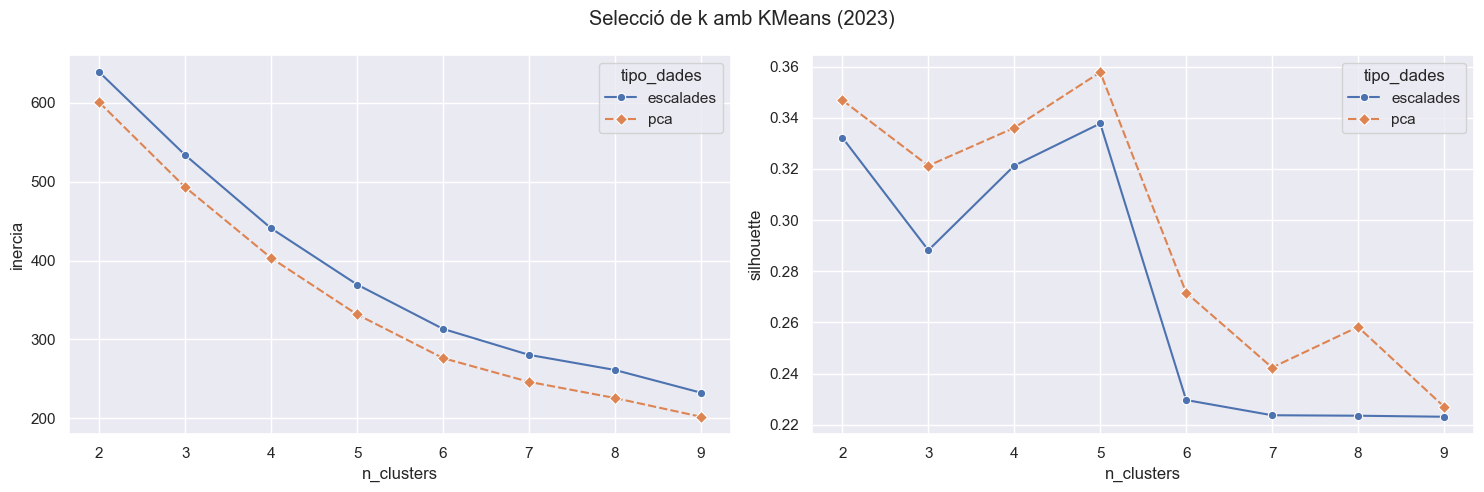

In [37]:
plot_seleccio_kmeans(resultats_2023_df, "2023", "seleccio_k_2023.png")

**Observacions:**
- Els resultats són lleugerament més bons amb les dades reduïdes. En aquest cas, el nombre de clúster òptim es veu molt clar en el gràfic de silhouette (5 clusters).


## Agglomerative Clustering

In [32]:
# Comparem clusters amb pca vs dades escalades
valors_k = range(2, 10)
agg_resultats_23 = []
for k in valors_k:
    agg_scaled = AgglomerativeClustering(n_clusters = k)
    agg_labels = agg_scaled.fit_predict(X_23_scaled)
    agg_resultats_23.append(evaluacio_cluster(agg_scaled, X_23_scaled, agg_labels, f"KMeans_{k}", "escalades"))

    agg_pca = AgglomerativeClustering(n_clusters = k)
    agg_labels = agg_pca.fit_predict(X_pca_23_fixed)
    agg_resultats_23.append(evaluacio_cluster(agg_pca, X_pca_23_fixed, agg_labels, f"KMeans_{k}", "pca"))


# Convertim a dataframe
agg_resultats_23_df = pd.DataFrame(agg_resultats_23)
agg_resultats_23_df

,model,tipo_dades,n_clusters,silhouette
0,KMeans_2,escalades,2,0.328572
1,KMeans_2,pca,2,0.344662
2,KMeans_3,escalades,3,0.330927
3,KMeans_3,pca,3,0.348426
4,KMeans_4,escalades,4,0.342290
5,KMeans_4,pca,4,0.360812
6,KMeans_5,escalades,5,0.344970
7,KMeans_5,pca,5,0.363864
8,KMeans_6,escalades,6,0.250595
9,KMeans_6,pca,6,0.318525


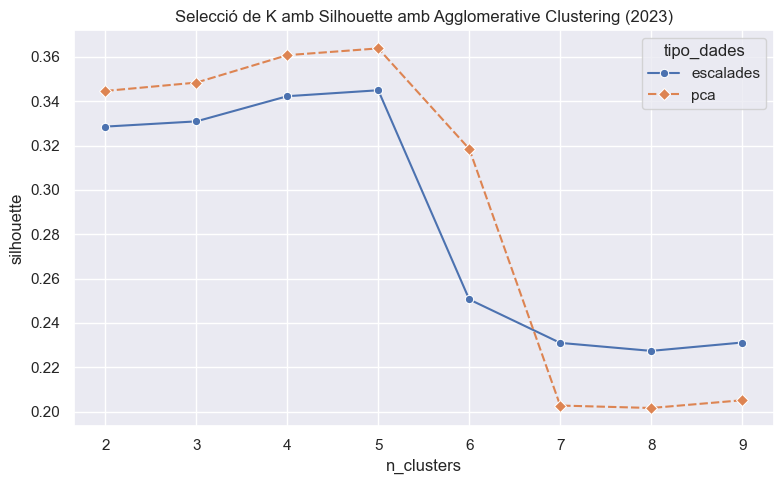

In [38]:
plot_seleccio_agg(agg_resultats_23_df, "2023", "seleccio_k_2023_agg.png")

**Observacions:**
- Nombre òptim de clusters es 5, tot i que amb 4 també s' obtenen bons resultats.
- El valor de silhouette amb k = 5 és lleugerament superior al obtingut amb KMeans.

## Deltes

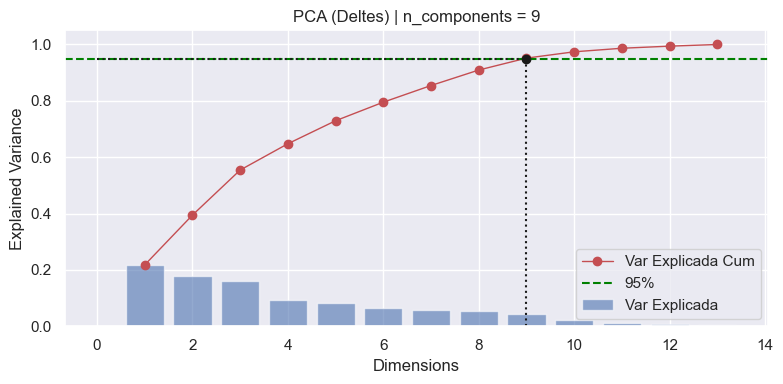

In [39]:
pca_deltes = PCA(random_state= 42)
pca_embedding = pca_deltes.fit_transform(X_deltes_scaled)
grafic_var_explicada(pca_deltes, 0.95, "PCA (Deltes)", "variança_explicada_deltes.png")

**Observacions:**
- Per al dataset de Deltes el nombre de dimensions necessari per explicar el 95% de la variança són 9 components

In [40]:
# apliquem pca amb el n_components obtingut anteriorment
n_components_deltes = 8

pca_deltes_fixed = PCA(n_components= n_components_deltes, random_state= 42)
X_pca_deltes_fixed = pca_deltes_fixed.fit_transform(X_deltes_scaled)

# Mostrem els resultats i components
X_pca_df = pd.DataFrame(X_pca_deltes_fixed, columns=[f'PC{i}' for i in range(1, n_components_deltes + 1)], index=df_deltes['codi_barri'])
X_pca_df.head()


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8
codi_barri,,,,,,,,
1,-0.980014,-0.018976,-0.894710,-0.306506,-0.843304,-0.733832,-0.381044,0.408758
2,8.088128,-6.964159,3.083901,0.869280,0.033609,-2.069919,0.295884,0.272596
3,0.129470,2.406112,0.920555,1.358246,-0.589647,-1.458344,-2.263409,-1.073216
4,-0.330542,1.020564,0.007152,0.840141,-0.729122,-1.036854,-0.986213,-0.587651
5,1.526405,0.896190,0.968208,0.493183,-0.451433,-0.782330,0.184429,-1.335207


In [41]:
## KMeans
# Comparem clusters amb pca vs dades escalades
valors_k = range(2, 10)
resultats_clusters_deltes = []
for k in valors_k:
    clusterer_scaled = KMeans(n_clusters = k, n_init = 20, random_state = 42)
    cluster_labels_scaled = clusterer_scaled.fit_predict(X_deltes_scaled)
    resultats_clusters_deltes.append(evaluacio_cluster(clusterer_scaled, X_deltes_scaled, cluster_labels_scaled, f"KMeans_{k}", "escalades"))

    clusterer_pca = KMeans(n_clusters = k, n_init = 20, random_state = 42)
    cluster_labels_pca = clusterer_pca.fit_predict(X_pca_deltes_fixed)
    resultats_clusters_deltes.append(evaluacio_cluster(clusterer_pca, X_pca_deltes_fixed, cluster_labels_pca, f"KMeans_{k}", "pca"))


# Convertim a dataframe
resultats_deltes_df = pd.DataFrame(resultats_clusters_deltes)
resultats_deltes_df

,model,tipo_dades,n_clusters,silhouette,inercia
0,KMeans_2,escalades,2,0.637086,817.482342
1,KMeans_2,pca,2,0.517696,732.008828
2,KMeans_3,escalades,3,0.631943,687.459681
3,KMeans_3,pca,3,0.650843,607.317287
4,KMeans_4,escalades,4,0.389792,576.843403
5,KMeans_4,pca,4,0.412413,497.326912
6,KMeans_5,escalades,5,0.297778,527.165623
7,KMeans_5,pca,5,0.160058,429.993688
8,KMeans_6,escalades,6,0.132726,465.268921
9,KMeans_6,pca,6,0.168688,379.343186


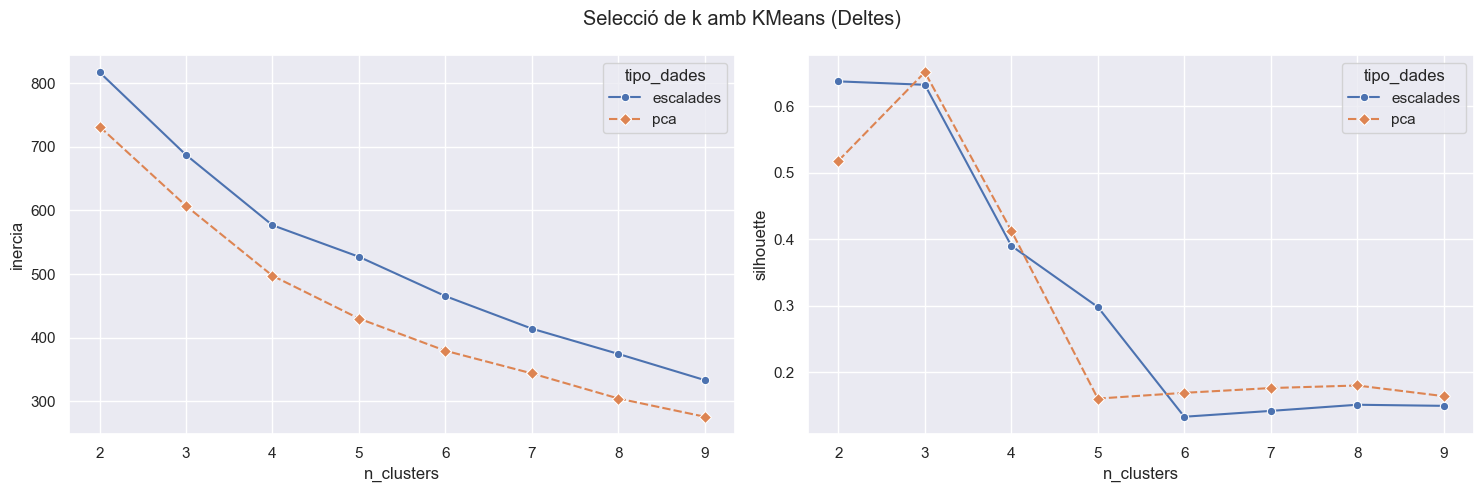

In [43]:
plot_seleccio_kmeans(resultats_deltes_df, "Deltes", "seleccio_k_deltes.png")

**Observacions:**
- Mentre que amb El mètode del colze, el nombre òptim de k és 4, en el gràfic dels valors de silhouette, k = 3 és el òptim, de fet k = 4 es redueix dràsticament el score. 

In [44]:
# Comparem clusters amb pca vs dades escalades
valors_k = range(2, 10)
agg_resultats_deltes = []
for k in valors_k:
    agg_scaled = AgglomerativeClustering(n_clusters = k)
    agg_labels = agg_scaled.fit_predict(X_deltes_scaled)
    agg_resultats_deltes.append(evaluacio_cluster(agg_scaled, X_deltes_scaled, agg_labels, f"KMeans_{k}", "escalades"))

    agg_pca = AgglomerativeClustering(n_clusters = k)
    agg_labels = agg_pca.fit_predict(X_pca_deltes_fixed)
    agg_resultats_deltes.append(evaluacio_cluster(agg_pca, X_pca_deltes_fixed, agg_labels, f"KMeans_{k}", "pca"))


# Convertim a dataframe
agg_resultats_deltes_df = pd.DataFrame(agg_resultats_deltes)
agg_resultats_deltes_df

,model,tipo_dades,n_clusters,silhouette
0,KMeans_2,escalades,2,0.638243
1,KMeans_2,pca,2,0.658290
2,KMeans_3,escalades,3,0.631943
3,KMeans_3,pca,3,0.650843
4,KMeans_4,escalades,4,0.441890
5,KMeans_4,pca,4,0.440336
6,KMeans_5,escalades,5,0.111397
7,KMeans_5,pca,5,0.124448
8,KMeans_6,escalades,6,0.118933
9,KMeans_6,pca,6,0.136324


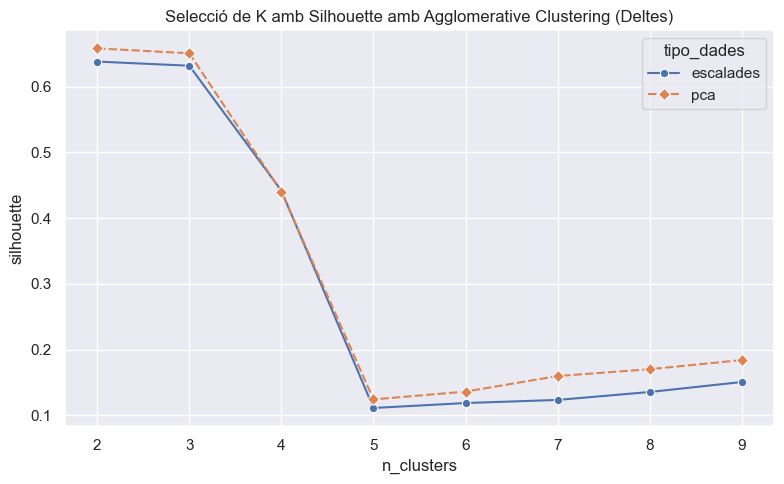

In [45]:
plot_seleccio_agg(agg_resultats_deltes_df, "Deltes", "seleccio_k_deltes_agg.png")

**Observacions:**
- Els resultats indiquen que el nombre de clusters optims per als deltes és de 2 o 3.
- Els resultats són similars a KMeans.